
*Saama Assignment - POC.   
Author: Manohar Karanam Mob: +91 9986858449)*


# Leveraging Principal Component Analysis (PCA) to reduce training parameters and training time, while maintaining performance metrics for Convolutional Neural Networks (CNN).
---------------------------------

## Concept:  
---------------
In order to process Image data for Deep Learning Algorithms , Convolutional Neural Networks (CNN) are the most suitable framework, as they process the image data using various filters.

Typical modern day camera images consists of millions of pixels per image and hence would need huge processing power to train any CNN performing at reasonably acceptable levels. Reducing the training parameters would help in improving training time & compute capacity. Given the inherent large size of typical CNNs, this gain can be considerable.  

Principal Component Analysis (PCA) is a dimensionality reduction that identifies important data relations in our data using SVD techniques, transforms the existing data based on these relationships utilising the concept of Eigen vectors and Eigen values, and then quantifies the importance of these combinations of principal components so that we can utilize the most important features for further processing. This drastically reduces the number of parameters required to retain the same variation in our data. These extracted PCAs are independent of the original data and capture all of the variance in original training data.

The methodology proposed in the POC below is to utilize the concepts of PCA while training the CNN in order to reduce the number of parameters to be trained, hence resulting in much less time & compute capacity required to train the CNN while ensuring there is no loss in performance.

## Applicability:
-----------------------
The combination of PCA and CNN can be applied to leveraged while training almost all CNN models. This combination will be of particular advantage when the CNN models have large size typically with multiple convolutional layers.

# Experimental Setup:
--------------------------
A random sample consisting of ~200 images consisting of 4 training classes is used to train the CNN. VGG16 pre trained model is used to levarage transfer of weights for most convolutional layers. A test set of ~80 images is used to test the model accuracy.

In the **first iteration**, all the features obtained through the images are used for training the CNN. The training time and accuracy of the model is noted for comparison.

In the **second iteration**, PCA methodology is used to obtain the principal components from the original set of features obtained from the images. The PCs are then used to train the second model. The training time, number of features and accuracy of the model is then compared with the model trained in the previous iteration.

# Results Comparison: 
---------------------------------------------------------
**First Iteration statistics:**

*Training parameters:*



> Total params: 8,389,892

> **Trainable params:** 8,389,892

> **Training time:** 16.05 seconds

*Test parameters:*
> **Accuracy:** 

>> Accuracy with Full Features =  **95.77%**



**Second Iteration statistics:**

*Training parameters:*


> Number of principal components used
**n_PCA_components = 65**

> Total params: 17,924

> **Trainable params:** 17,924

> **Training time:** 01.12 seconds


*Test parameters:*
> **Accuracy:** 

>> Accuracy with PCA Features =  **94.36%**



## Conclusion:
----------------


*   There is significant reduction in the number of parameters used for training the model. (**~8.4M parameters reduced to ~18K parameters, >460X gain**)




*   There is significant improvement in training time of the model (**16.05s reduced to 01.12s, >14X gain**)



*   There is a negligible impact on the accuracy of the model (**95.77% Accuracy reduced to 94.36%, ~1% loss in accuracy**)


* This would also lead to proportionate **reduction in the compute capacity and energy utilization** for training large CNNs.




The concept of PCA has been successfully leveraged while training CNNs in order to improve training time with reduced number of parameters while maintaining accuracy of the final model. The gain in training time can be much more pronounced while training much larger models & many more images, especially in a large commercial setup. 


In [2]:
#Standard Imports
import numpy as np 
import matplotlib.pyplot as plt
import glob
import cv2
import os
import seaborn as sns

# Standard Keras modules 
from keras.models import Model, Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.layers import BatchNormalization

# Importing VGG16 pre trained model to enable transfer learnig
from keras.applications.vgg16 import VGG16

In [3]:
os.chdir('/content/drive/MyDrive/Unsplash_Downloads/Train_Data')
print(os.listdir("dataset/"))

['Banyan', 'Tiger', 'Lotus', 'Peacock']


In [ ]:
SIZE = 256  #Resize images

#Capture training data and labels into respective lists
train_images = []
train_labels = [] 

for directory_path in glob.glob("dataset/*"):
    label = directory_path.split("/")[-1]
    print(label)
    for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
        print(img_path)
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)       
        img = cv2.resize(img, (SIZE, SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        train_images.append(img)
        train_labels.append(label)

#Convert lists to arrays        
train_images = np.array(train_images)
train_labels = np.array(train_labels)


In [5]:
os.chdir('/content/drive/MyDrive/Unsplash_Downloads/Test_Data')
print(os.listdir("dataset/"))

['Banyan', 'Lotus', 'Peacock', 'Tiger']


In [ ]:
test_images = []
test_labels = [] 
for directory_path in glob.glob("dataset/*"):
    fruit_label = directory_path.split("/")[-1]
    print(fruit_label)
    for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
        print(img_path)
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (SIZE, SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        test_images.append(img)
        test_labels.append(fruit_label)

#Convert lists to arrays                
test_images = np.array(test_images)
test_labels = np.array(test_labels)

In [7]:
#Encode labels from text to integers.
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(test_labels)
test_labels_encoded = le.transform(test_labels)
le.fit(train_labels)
train_labels_encoded = le.transform(train_labels)

#Split data into test and train datasets (already split but assigning to meaningful convention)
x_train, y_train, x_test, y_test = train_images, train_labels_encoded, test_images, test_labels_encoded

In [8]:
###################################################################
# Scale pixel values to between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

#One hot encode y values for neural network. Not needed for Random Forest
from keras.utils import to_categorical
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

In [9]:
#############################
#Load VGG model with imagenet trained weights and without classifier/fully connected layers
#We will use this as feature extractor. 
VGG_model = VGG16(weights='imagenet', include_top=False, input_shape=(SIZE, SIZE, 3))

#Make loaded layers as non-trainable. This is important as we want to work with pre-trained weights
for layer in VGG_model.layers:
	layer.trainable = False
    
VGG_model.summary()  #Trainable parameters will be 0

58889256/58889256 [==============================] - 0s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 256, 256, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 256, 256, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 128, 128, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 128, 128, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 128, 128, 128)     147584    
                                                              

In [10]:
#Now, let us extract features using VGG imagenet weights
#Train features
train_feature_extractor=VGG_model.predict(x_train)
train_features = train_feature_extractor.reshape(train_feature_extractor.shape[0], -1)
#test features
test_feature_extractor=VGG_model.predict(x_test)
test_features = test_feature_extractor.reshape(test_feature_extractor.shape[0], -1)

3/3 [==============================] - 52s 15s/step


# Iteration 1:

In this Iteration we will train the CNN with full set of features obtained from the images

In [11]:
Full_Train_Count,Full_Train_Len =  train_features.shape
print(Full_Train_Count, Full_Train_Len)

168 32768


In [12]:
##Add hidden dense layers and final output/classifier layer.
model = Sequential()
inputs = Input(shape=(Full_Train_Len,))
#inputs = Input(shape=(n_PCA_components,)) #Shape = n_components
hidden = Dense(256, activation='relu')(inputs)
#hidden1 = Dense(512, activation='relu')(inputs)
#hidden2 = Dense(256, activation='relu')(hidden1)
output = Dense(4, activation='softmax')(hidden)
model = Model(inputs=inputs, outputs=output)

print(model.summary())

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 32768)]           0         
                                                                 
 dense (Dense)               (None, 256)               8388864   
                                                                 
 dense_1 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 8,389,892
Trainable params: 8,389,892
Non-trainable params: 0
_________________________________________________________________
None


In [13]:
#
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['categorical_accuracy'])

In [14]:
#Train with original features
import datetime
start = datetime.datetime.now()
#Fit the model. Do not forget to use on-hot-encoded Y values. 
model.fit(train_features, y_train_one_hot, epochs=20, verbose=1)

end = datetime.datetime.now()
print("Total execution time with Full set of training features is: ", end-start)

Epoch 1/20
6/6 [==============================] - 1s 114ms/step - loss: 17.1435 - categorical_accuracy: 0.2262
Epoch 2/20
6/6 [==============================] - 1s 120ms/step - loss: 0.4268 - categorical_accuracy: 0.8333
Epoch 3/20
6/6 [==============================] - 1s 115ms/step - loss: 0.7399 - categorical_accuracy: 0.8274
Epoch 4/20
6/6 [==============================] - 1s 112ms/step - loss: 0.0631 - categorical_accuracy: 0.9940
Epoch 5/20
6/6 [==============================] - 1s 111ms/step - loss: 0.0244 - categorical_accuracy: 1.0000
Epoch 6/20
6/6 [==============================] - 1s 114ms/step - loss: 0.0627 - categorical_accuracy: 0.9821
Epoch 7/20
6/6 [==============================] - 1s 112ms/step - loss: 0.8907 - categorical_accuracy: 0.8155
Epoch 8/20
6/6 [==============================] - 1s 114ms/step - loss: 0.3606 - categorical_accuracy: 0.9167
Epoch 9/20
6/6 [==============================] - 1s 143ms/step - loss: 0.0083 - categorical_accuracy: 1.0000
Epoch 10/

In [15]:
##Predict on test dataset
predict_test = model.predict(test_features)
predict_test = np.argmax(predict_test, axis=1)
predict_test = le.inverse_transform(predict_test)
#
#

3/3 [==============================] - 0s 12ms/step


Accuracy with Full Features =  0.9577464788732394


<AxesSubplot:>

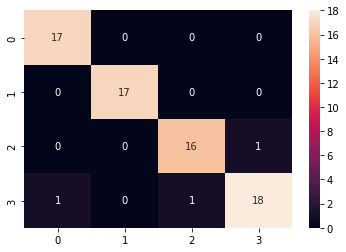

In [16]:
##Print overall accuracy
from sklearn import metrics
print ("Accuracy with Full Features = ", metrics.accuracy_score(test_labels, predict_test))

#Confusion Matrix - verify accuracy of each class
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, predict_test)
#print(cm)
sns.heatmap(cm, annot=True)

# Iteration 2
In this iteration, we will utilize PCA technique to reduce the number of parameters to be trained.  

Text(0, 0.5, 'Cum variance')

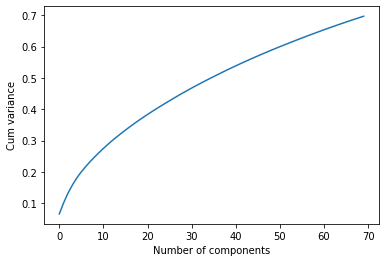

In [17]:
# Reduce dimensions using PCA
from sklearn.decomposition import PCA

#First verfiy the ideal number of PCA components to not lose much information. 
#Try to retain 90% information, so look where the curve starts to flatten.
#Remember that the n_components must be lower than the number of rows or columns (features)
pca_test = PCA(n_components=70) #
pca_test.fit(train_features)
plt.plot(np.cumsum(pca_test.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cum variance")

## While checking the variance of data, we can see that ~65 components contain about 70 percent of variance in the original data. Hence 65 PCs are chosen for further processing.

In [18]:
#Pick the optimal number of components. This is how many features we will have 
#for our machine learning
n_PCA_components = 65
pca = PCA(n_components=n_PCA_components)
train_PCA = pca.fit_transform(train_features)
test_PCA = pca.transform(test_features) #Make sure you are just transforming, not fitting. 

print(train_PCA.shape)

(168, 65)


In [19]:
#Training a new model with PCA features only
##Add hidden dense layers and final output/classifier layer.
PCA_model = Sequential()
#inputs = Input(shape=(Full_Train_Len,))
inputs = Input(shape=(n_PCA_components,)) #Shape = n_components
hidden = Dense(256, activation='relu')(inputs)
#hidden1 = Dense(512, activation='relu')(inputs)
#hidden2 = Dense(256, activation='relu')(hidden1)
output = Dense(4, activation='softmax')(hidden)
PCA_model = Model(inputs=inputs, outputs=output)

print(PCA_model.summary())

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 65)]              0         
                                                                 
 dense_2 (Dense)             (None, 256)               16896     
                                                                 
 dense_3 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 17,924
Trainable params: 17,924
Non-trainable params: 0
_________________________________________________________________
None


In [20]:
#
PCA_model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['categorical_accuracy'])

In [21]:
#Train with PCA reduced dimensions
import datetime
start = datetime.datetime.now()
#Fit the model. Do not forget to use on-hot-encoded Y values. 
PCA_model.fit(train_PCA, y_train_one_hot, epochs=20, verbose=1)

end = datetime.datetime.now()
print("Total execution time with PCA is: ", end-start)

Epoch 1/20
6/6 [==============================] - 0s 3ms/step - loss: 2.9984 - categorical_accuracy: 0.2679
Epoch 2/20
6/6 [==============================] - 0s 3ms/step - loss: 0.8345 - categorical_accuracy: 0.7143
Epoch 3/20
6/6 [==============================] - 0s 3ms/step - loss: 0.3693 - categorical_accuracy: 0.8929
Epoch 4/20
6/6 [==============================] - 0s 3ms/step - loss: 0.2275 - categorical_accuracy: 0.9405
Epoch 5/20
6/6 [==============================] - 0s 2ms/step - loss: 0.1398 - categorical_accuracy: 0.9762
Epoch 6/20
6/6 [==============================] - 0s 3ms/step - loss: 0.0957 - categorical_accuracy: 0.9940
Epoch 7/20
6/6 [==============================] - 0s 2ms/step - loss: 0.0659 - categorical_accuracy: 1.0000
Epoch 8/20
6/6 [==============================] - 0s 4ms/step - loss: 0.0476 - categorical_accuracy: 1.0000
Epoch 9/20
6/6 [==============================] - 0s 3ms/step - loss: 0.0366 - categorical_accuracy: 1.0000
Epoch 10/20
6/6 [===========

In [22]:
##Predict on test dataset
predict_test_PCA = PCA_model.predict(test_PCA)
predict_test_PCA = np.argmax(predict_test_PCA, axis=1)
predict_test_PCA = le.inverse_transform(predict_test_PCA)
#
#

3/3 [==============================] - 0s 3ms/step


Accuracy with PCA Features =  0.9436619718309859


<AxesSubplot:>

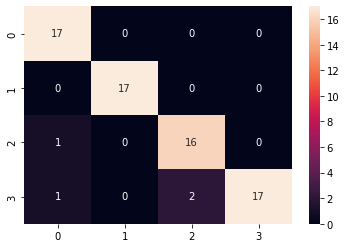

In [23]:
##Print overall accuracy
from sklearn import metrics
print ("Accuracy with PCA Features = ", metrics.accuracy_score(test_labels, predict_test_PCA))

#Confusion Matrix - verify accuracy of each class
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, predict_test_PCA)
#print(cm)
sns.heatmap(cm, annot=True)

## Just to ensure that the model output make sense, a simple manual check is done on a random image from the test set.

1/1 [==============================] - 0s 33ms/step
The prediction for this image is:  ['Banyan']
The actual label for this image is:  Banyan


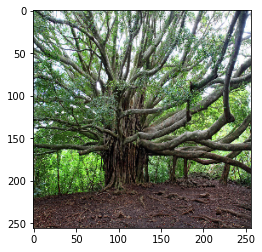

In [24]:
#Check results on a few select images
n=np.random.randint(0, x_test.shape[0])
img = x_test[n]
plt.imshow(img)

input_img = np.expand_dims(img, axis=0) #Expand dims so the input is (num images, x, y, c)
input_img_feature=VGG_model.predict(input_img)
input_img_features=input_img_feature.reshape(input_img_feature.shape[0], -1)
input_img_PCA = pca.transform(input_img_features)
prediction_img = PCA_model.predict(input_img_PCA)
prediction_img = np.argmax(prediction_img, axis=1)
prediction_img = le.inverse_transform(prediction_img)  #Reverse the label encoder to original name
print("The prediction for this image is: ", prediction_img)
print("The actual label for this image is: ", test_labels[n])

## As evident from the results, the PCA dimensionality reduction technique allows us to train CNN with much less number of parameters while capturing most variation of original data. This helps in improving training time & compute resource requirement, while maintaining similar performance to using full set of features.